# Model Training and Evaluation

This notebook focuses on training and evaluating multiple regression models for laptop price prediction.

The workflow includes:

- Loading the processed dataset
- Separating features and target
- Splitting the data into training and testing sets
- Identifying numerical and categorical features
- Building a preprocessing pipeline
- Validating the transformed data
- Training a Linear Regression baseline
- Training additional regression models
- Comparing model performance using MAE, RMSE, and R²
- Visualizing and analyzing the model results

In [2]:
import joblib
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

from xgboost import XGBRegressor
plt.style.use("ggplot")

## 1. Load Dataset

load data from `../data/processed/laptops_features.csv`

In [3]:
df = pd.read_csv("../data/processed/laptops_features.csv")

print("Data load successfully...")

FileNotFoundError: [Errno 2] No such file or directory: '../data/processed/laptops_features.csv'

In [ ]:
df.head()

,brand,Price,Rating,processor_brand,processor_tier,num_cores,num_threads,ram_memory,primary_storage_type,primary_storage_capacity,...,gpu_type,is_touch_screen,display_size,resolution_width,resolution_height,OS,year_of_warranty,total_storage_capacity,total_pixels,ppi
0,tecno,23990,63,intel,core i3,2,4,8,SSD,512,...,integrated,False,15.6,1920,1080,windows,1.0,512,2073600,141.211998
1,tecno,35990,67,intel,core i7,4,8,16,SSD,1024,...,integrated,False,15.6,1920,1080,windows,1.0,1024,2073600,141.211998
2,hp,51100,73,amd,ryzen 5,6,12,8,SSD,512,...,dedicated,False,15.6,1920,1080,windows,1.0,512,2073600,141.211998
3,acer,39990,62,intel,core i5,12,16,8,SSD,512,...,integrated,False,14.0,1920,1080,windows,1.0,512,2073600,157.350512
4,lenovo,28580,62,amd,ryzen 3,4,8,8,SSD,512,...,integrated,False,15.6,1920,1080,windows,1.0,512,2073600,141.211998


## 2. Separate Features and Target

`Price` is the target variable that the regression models will learn to predict.

In [ ]:
X = df.drop(columns=["Price"])
y = df["Price"]

## 3. Split the Dataset

The dataset is divided into training and testing sets using an 80:20 split.

- **Training set (80%)** is used to train the models.
- **Testing set (20%)** is used to evaluate model performance on unseen data.

A fixed `random_state` is used to make the split reproducible.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (792, 22)
Testing set: (199, 22)


## 4. Separate `Numerical` and `Categorical` Features
The features are divided into numerical and categorical groups because each type requires a different preprocessing strategy.

- Numerical features will undergo imputation and scaling.
- Categorical features will undergo imputation and one-hot encoding.


In [ ]:
bool_cols = X_train.select_dtypes(include="bool").columns.tolist()
X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols] = X_test[bool_cols].astype(int)

numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

NameError: name 'X_train' is not defined

## 5. Build Preprocessing Pipeline

A `ColumnTransformer` is used to apply separate preprocessing pipelines to numerical and categorical features.

### Numerical Features
- Missing values are handled using median imputation.
- Features are standardized using `StandardScaler`.

### Categorical Features
- Missing values are handled using the most frequent category.
- Categories are converted into numerical features using `OneHotEncoder`.

The preprocessing pipeline is fitted only on the training data to prevent data leakage.

In [ ]:
num_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy='median')), 
        ("scaler", StandardScaler())
    ]
)

cat_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]
)

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", num_pipeline, numeric_features),
        ("categorical", cat_pipeline, categorical_features)
    ],
    remainder="drop"
)

In [ ]:
X_train_transformed = preprocessor.fit_transform(X_train)

In [ ]:
X_test_transformed  = preprocessor.transform(X_test)

## Save the Models and Data

In [ ]:
os.makedirs("../src/models", exist_ok=True)

joblib.dump(
    preprocessor, 
    "../src/models/preprocessor.pkl"
)

joblib.dump(
    {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test
    },
    "../src/models/train_test_data.pkl"
)

print("Models saved Successfully...")

Models saved Successfully...


## 6. Validate Preprocessed Data

The transformed training and testing data are checked to ensure that preprocessing has successfully handled missing values and converted all features into numerical form.

In [ ]:
print("Training shape:", X_train_transformed.shape)
print("Testing shape:", X_test_transformed.shape)

Training shape: (792, 75)
Testing shape: (199, 75)


In [ ]:
print("Missing values in training:", np.isnan(X_train_transformed).sum())
print("Missing values in testing:", np.isnan(X_test_transformed).sum())

Missing values in training: 0
Missing values in testing: 0


In [ ]:
print("Training dtype:", X_train_transformed.dtype)
print("Testing dtype:", X_test_transformed.dtype)

Training dtype: float64
Testing dtype: float64


### Helper: evaluate()

A small helper avoids repeating the same MAE/RMSE/R² block for every model below.

In [ ]:
def evaluate(name, y_true, y_pred):
    """Compute MAE, RMSE, R2 for a model's predictions, print them, and
    return a one-row DataFrame that can be appended to the metrics table."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"{name}")
    print(f"MAE  : ₹{mae:,.2f}")
    print(f"RMSE : ₹{rmse:,.2f}")
    print(f"R2   : {r2:.4f}")

    return pd.DataFrame({"Model": [name], "MAE": [mae], "RMSE": [rmse], "R2": [r2]})

## 7. Baseline Model — Linear Regression

Linear Regression is used as the baseline model.

The baseline provides a simple reference point against which more complex regression models can be compared.

In [ ]:
linear_model = LinearRegression()

linear_model.fit(X_train_transformed, y_train)

In [ ]:
y_pred = linear_model.predict(X_test_transformed)

## 8. Evaluate Baseline Model

The trained Linear Regression model is evaluated on the unseen test set using three regression metrics:

- **MAE (Mean Absolute Error):** measures the average absolute difference between actual and predicted prices.
- **RMSE (Root Mean Squared Error):** measures prediction error while giving greater weight to larger errors.
- **R² Score:** measures how well the model explains the variation in laptop prices.

These metrics provide a baseline performance that will be used to compare more advanced regression models.

In [ ]:
metrics = evaluate("Linear Regression", y_test, y_pred)
metrics

## 9. Actual vs Predicted Prices

The actual and predicted laptop prices are visualized to understand how closely the Linear Regression model's predictions follow the true prices.

Points closer to the diagonal reference line indicate more accurate predictions.

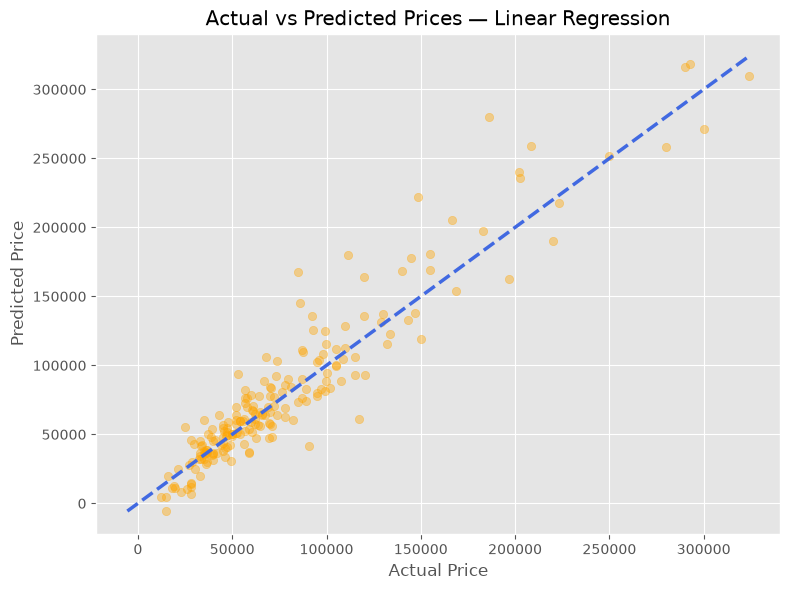

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.4,
    color='orange'
)

lims = [
    min(y_test.min(), y_pred.min()),
    max(y_test.max(), y_pred.max())
]

plt.plot(
    lims,
    lims,
    linestyle="--",
    color='royalblue',
    linewidth=2.5
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices — Linear Regression")

plt.tight_layout()
plt.show()

## 10. Train Additional Regression Models

Linear Regression provides the baseline performance. More flexible regression models will now be trained to capture nonlinear relationships between laptop specifications and price.

The models will be evaluated using the same test set and the same preprocessing pipeline for a fair comparison.

### 10.1 Random Forest Regressor

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=300, 
    random_state=42, 
    n_jobs=-1
)

rf_model.fit(X_train_transformed, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [ ]:
y_pred_rf = rf_model.predict(X_test_transformed)

In [ ]:
metrics = pd.concat([metrics, evaluate("Random Forest", y_test, y_pred_rf)], ignore_index=True)

### 10.2 Gradient Boosting

In [ ]:
gb_model = GradientBoostingRegressor(
    n_estimators=300, 
    learning_rate=0.05, 
    max_depth=4, 
    random_state=42
)
gb_model.fit(X_train_transformed, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",4
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft

In [ ]:
y_pred_gb = gb_model.predict(X_test_transformed)

In [ ]:
metrics = pd.concat([metrics, evaluate("Gradient Boosting", y_test, y_pred_gb)], ignore_index=True)

### 10.3 XGBoost

In [ ]:
xg_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

xg_model.fit(X_train_transformed, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [ ]:
y_pred_xg = xg_model.predict(X_test_transformed)

In [ ]:
metrics = pd.concat([metrics, evaluate("XGBoost", y_test, y_pred_xg)], ignore_index=True)

### 10.4 K-Nearest Neighbors Regressor

In [ ]:
knn_model = KNeighborsRegressor(
    n_neighbors=5, 
    weights='distance',
    p=2,
    n_jobs=-1
)

knn_model.fit(X_train_transformed, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",-1


In [ ]:
y_pred_knn = knn_model.predict(X_test_transformed)

In [ ]:
metrics = pd.concat([metrics, evaluate("KNN", y_test, y_pred_knn)], ignore_index=True)

## 11. Compare Model Performance

The performance of all trained models is compared using MAE, RMSE, and R².

- **Lower MAE** indicates smaller average prediction errors.
- **Lower RMSE** indicates smaller errors and penalizes large errors more strongly.
- **Higher R²** indicates that the model explains a larger proportion of the variation in laptop prices.

The models are ranked primarily using R² to identify the strongest overall model.

In [ ]:
metrics = metrics.sort_values(
    by="R2",
    ascending=False
).reset_index(drop=True)

metrics = metrics.round(2)

metrics

,Model,MAE,RMSE,R2
0,Gradient Boost,11043.35,18206.07,0.90
1,Gradient Boost,11043.35,18206.07,0.90
2,XGBoost,11498.34,19701.21,0.88
3,XGBoost,11498.34,19701.21,0.88
4,Linear Regression,14130.92,20388.59,0.87
5,Random Forest,12140.52,20841.67,0.86
6,KNN,12322.92,22270.33,0.84
7,KNN,12322.92,22270.33,0.84


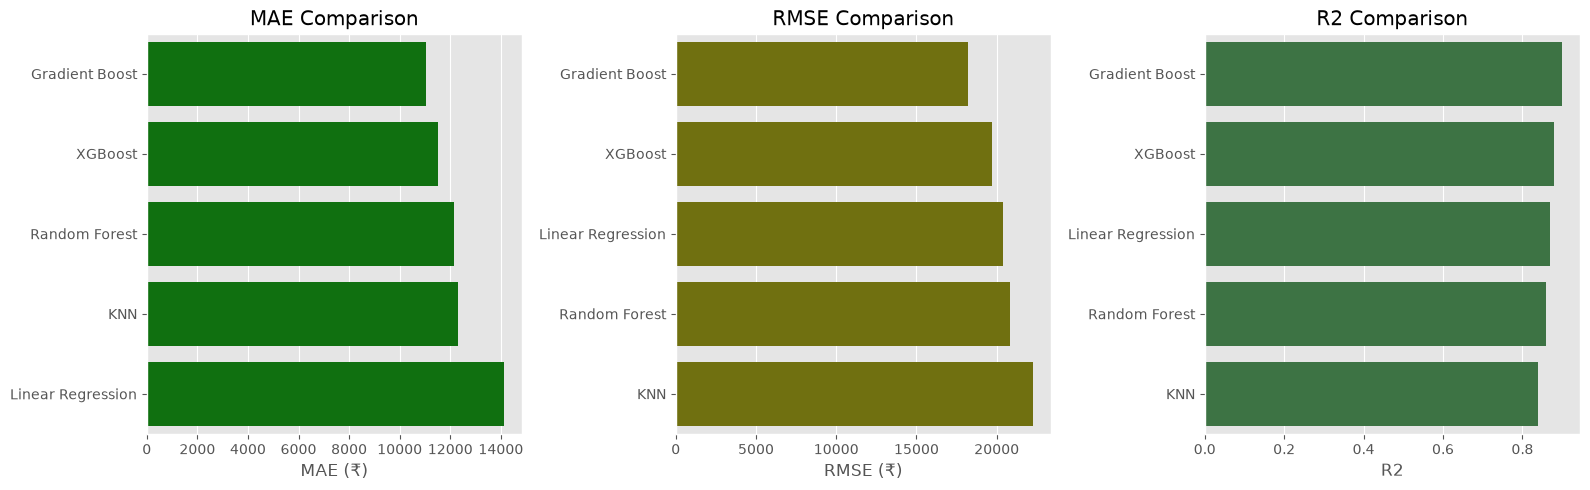

In [ ]:
fig, axes = plt.subplots(
    1, 3,
    figsize=(16, 5)
)

sns.barplot(
    data=metrics.sort_values("MAE"),
    x="MAE",
    y="Model",
    ax=axes[0], 
    color='green'
)
axes[0].set_title("MAE Comparison")
axes[0].set_xlabel("MAE (₹)")
axes[0].set_ylabel("")

sns.barplot(
    data=metrics.sort_values("RMSE"),
    x="RMSE",
    y="Model",
    ax=axes[1],
    color='olive'
)
axes[1].set_title("RMSE Comparison")
axes[1].set_xlabel("RMSE (₹)")
axes[1].set_ylabel("")

sns.barplot(
    data=metrics.sort_values("R2", ascending=False),
    x="R2",
    y="Model",
    ax=axes[2],
    color="#347C3D"
)
axes[2].set_title("R2 Comparison")
axes[2].set_xlabel("R2")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

### Observations

- Gradient Boosting achieves the lowest MAE and RMSE among the evaluated models, indicating the smallest average prediction errors.
- Gradient Boosting also achieves the highest R2 score of approximately 0.896, explaining about 89.6% of the variation in laptop prices.
- XGBoost performs competitively but remains slightly behind Gradient Boosting across all three evaluation metrics.
- KNN and Random Forest perform reasonably well, while Linear Regression provides the weakest overall performance, indicating that nonlinear models are better suited to this dataset.

## save Gradient Boost as BaseLine model

In [ ]:
joblib.dump(
    gb_model, 
    "../src/models/gb_baseline.pkl"
)

print("Models saved successfully...")

Models saved successfully...
